In [213]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

Memanggil Library yang akan digunakan pada kode
matplotlib.pyplot digunakan untuk menampilkan gambar dan grafik seperti histogram
matplotlib.image memungkinkan pembacaan dan penyimpanan gambar
cv2 digunakan untuk membaca gambar, mengubah ke grayscale, rotasi, flip, crop

cv2.imread(..., cv2.IMREAD_GRAYSCALE) digunakan agar gambar dibaca dalam mode grayscale
cmap='gray' agar ditampilkan dalam warna hitam-putih

Text(0.5, 1.0, 'Citra 2')

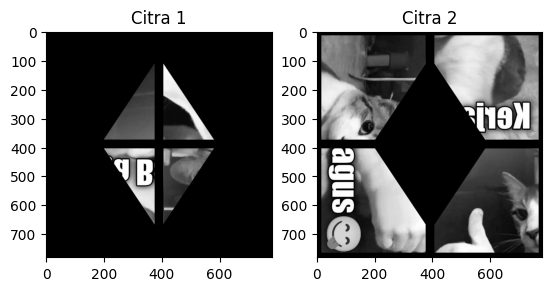

In [214]:
# baca gambar
img1 = cv2.imread('assets/citra1.jpeg')
img2 = cv2.imread('assets/citra2.jpeg')

# ubah ke grayscale (WAJIB dari soal)
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# tampilkan
plt.subplot(1, 2, 1)
plt.imshow(gray1, cmap='gray')
plt.title('Citra 1')

plt.subplot(1, 2, 2)
plt.imshow(gray2, cmap='gray')
plt.title('Citra 2')

Fungsi rotasi tersebut bertujuan untuk memutar citra secara manual dengan memindahkan posisi setiap piksel ke koordinat baru berdasarkan sudut 90, 180, atau 270 derajat. Pertama, kode menentukan dimensi citra dan menyiapkan wadah baru dengan ukuran yang sesuai, kemudian melakukan perulangan pada setiap piksel untuk memetakan posisinya ke lokasi yang baru sesuai dengan rotasi yang diinginkan. Untuk rotasi 90 dan 270 derajat, dimensi lebar dan tinggi citra ditukar, sedangkan untuk 180 derajat dimensinya tetap sama. Jika sudut yang dimasukkan tidak sesuai dengan ketiga pilihan tersebut, fungsi akan langsung mengembalikan citra asli tanpa melakukan perubahan apa pun. Setelah proses rotasi selesai, hasil akhirnya ditampilkan menggunakan fungsi matplotlib untuk melihat perubahan orientasi citra tersebut.

Text(0.5, 1.0, 'Rotasi Citra 1')

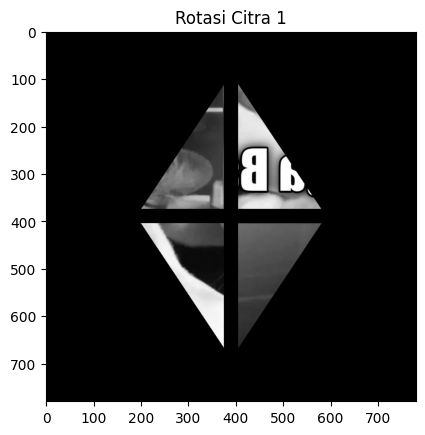

In [215]:
def rotasi(image, sudut):
    h, w = image.shape
    
    if sudut == 90:
        hasil = np.zeros((w, h), dtype=image.dtype)
        for i in range(h):
            for j in range(w):
                hasil[j, h-1-i] = image[i, j]
    
    elif sudut == 180:
        hasil = np.zeros((h, w), dtype=image.dtype)
        for i in range(h):
            for j in range(w):
                hasil[h-1-i, w-1-j] = image[i, j]
    
    elif sudut == 270:
        hasil = np.zeros((w, h), dtype=image.dtype)
        for i in range(h):
            for j in range(w):
                hasil[w-1-j, i] = image[i, j]
    
    else:
        return image
    
    return hasil

# coba rotasi (biasanya 90 atau 270)
rot1 = rotasi(gray1, 180)

plt.imshow(rot1, cmap='gray')
plt.title('Rotasi Citra 1')

Kode tersebut menjumlahkan piksel dari citra rot1 dan gray2 untuk menumpuk kedua gambar menjadi satu variabel bernama gabung. Hasilnya kemudian ditampilkan sebagai gambar grayscale tanpa garis sumbu koordinat melalui matplotlib. Perlu diingat bahwa jika total nilai piksel melebihi batas (seperti 255), area tersebut akan tampak putih polos atau mengalami saturasi.

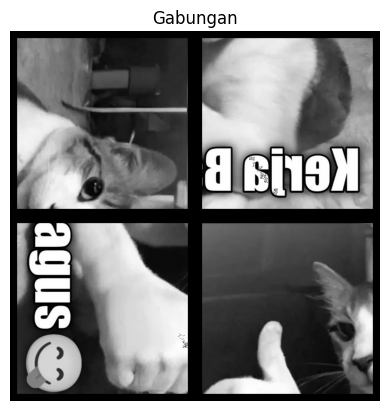

In [229]:
gabung = rot1 + gray2

plt.imshow(gabung, cmap='gray')
plt.title('Gabungan')
plt.axis('off')
plt.show()

Kode ini membagi citra gabung menjadi empat bagian sama besar (kuadran) menggunakan teknik slicing berdasarkan koordinat tengah tinggi dan lebarnya. Potongan tersebut kemudian ditampilkan dalam satu bingkai menggunakan layout grid 2x2 melalui fungsi subplot matplotlib. Meskipun terdapat sedikit kesalahan penamaan variabel pada bagian subplot yang tertukar, secara teknis kode ini memvisualisasikan setiap sudut citra secara terpisah.

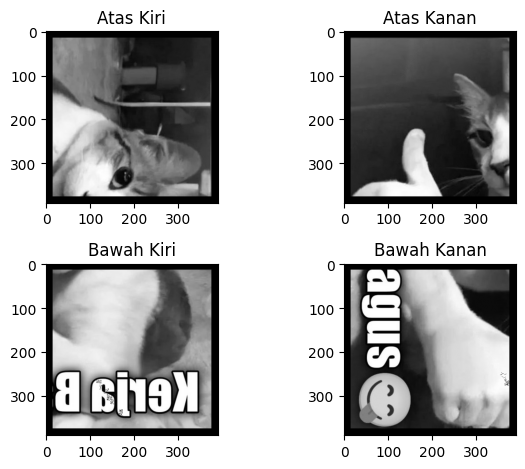

In [232]:
h, w = gabung.shape

atas_kiri = gabung[0:h//2, 0:w//2]
atas_kanan = gabung[0:h//2, w//2:w]
bawah_kiri = gabung[h//2:h, 0:w//2]
bawah_kanan = gabung[h//2:h, w//2:w]

plt.subplot(2, 2, 1)
plt.imshow(atas_kiri, cmap='gray')
plt.title('Atas Kiri')
plt.subplot(2, 2, 2)
plt.imshow(bawah_kanan, cmap='gray')
plt.title('Atas Kanan')
plt.subplot(2, 2, 3)
plt.imshow(atas_kanan, cmap='gray')
plt.title('Bawah Kiri')
plt.subplot(2, 2, 4)
plt.imshow(bawah_kiri, cmap='gray')
plt.title('Bawah Kanan')
plt.tight_layout()

Kode ini mendefinisikan fungsi flip untuk membalik posisi piksel citra secara horizontal jika mode x dipilih atau vertikal jika mode y dipilih dengan menukar indeks baris atau kolom. Setelah fungsi didefinisikan, tiga dari empat bagian kuadra yang sebelumnya dibagi kini dibalik posisinya menggunakan fungsi tersebut. Terakhir, seluruh potongan citra yang telah dimodifikasi ditampilkan kembali dalam tata letak grid 2x2 menggunakan matplotlib, selain itu terdapat perintah tambahan untuk menampilkan citra hasil konvolusi yang sudah ada sebelumnya.

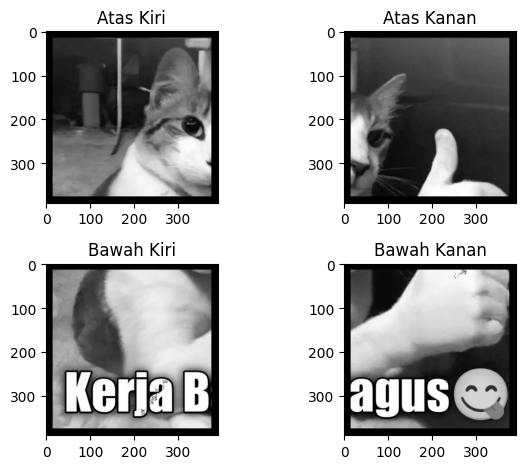

In [246]:
def flip(image, mode='x'):
    h, w = image.shape
    hasil = np.zeros((h, w))
    
    for i in range(h):
        for j in range(w):
            if mode == 'x':
                hasil[i, j] = image[i, w-1-j]
            else:
                hasil[i, j] = image[h-1-i, j]
    
    return hasil

# contoh
atas_kanan = flip(atas_kanan, 'x')
bawah_kanan = flip(bawah_kanan, 'y')

plt.subplot(2, 2, 1)
plt.imshow(atas_kiri, cmap='gray')
plt.title('Atas Kiri')
plt.subplot(2, 2, 2)
plt.imshow(bawah_kanan, cmap='gray')
plt.title('Atas Kanan')
plt.subplot(2, 2, 3)
plt.imshow(atas_kanan, cmap='gray')
plt.title('Bawah Kiri')
plt.subplot(2, 2, 4)
plt.imshow(bawah_kiri, cmap='gray')
plt.title('Bawah Kanan')
plt.tight_layout()

Kode ini memutar dua bagian citra, yaitu atas_kiri dan bawah_kiri, sejauh 90 derajat menggunakan fungsi rotasi yang telah dibuat sebelumnya. Setelah itu, semua potongan citra yang sudah dimodifikasi (baik yang diputar maupun yang dibalik pada tahap sebelumnya) disusun kembali ke dalam grid visual 2x2 menggunakan matplotlib. Tujuannya adalah untuk menampilkan orientasi baru dari setiap kuadran citra tersebut secara berdampingan dalam satu bingkai gambar agar perubahannya dapat dibandingkan.

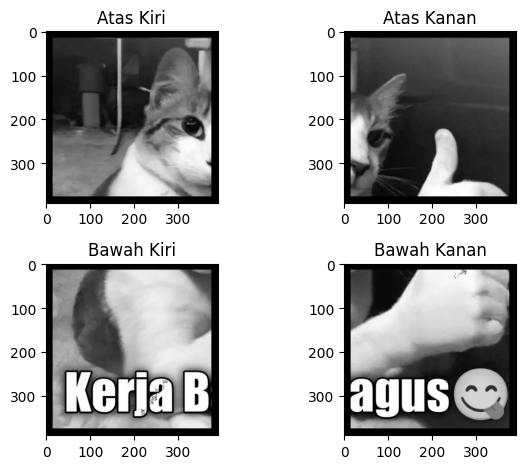

In [250]:
atas_kiri = rotasi(atas_kiri, 90)
bawah_kiri = rotasi(bawah_kiri, 90)

plt.subplot(2, 2, 1)
plt.imshow(atas_kiri, cmap='gray')
plt.title('Atas Kiri')
plt.subplot(2, 2, 2)
plt.imshow(bawah_kanan, cmap='gray')
plt.title('Atas Kanan')
plt.subplot(2, 2, 3)
plt.imshow(atas_kanan, cmap='gray')
plt.title('Bawah Kiri')
plt.subplot(2, 2, 4)
plt.imshow(bawah_kiri, cmap='gray')
plt.title('Bawah Kanan')
plt.tight_layout()

Kode ini melakukan proses pembesaran citra atau dilatasi pada setiap kuadran dengan skala dua kali lipat dari ukuran aslinya. Fungsi dilatasi bekerja dengan membuat array baru yang memiliki dimensi dua kali lebih besar, kemudian mengisi setiap piksel di koordinat baru dengan mengambil nilai dari piksel asli menggunakan pembagian integer (indeks i//2 dan j//2), yang secara efektif menduplikasi setiap piksel menjadi blok 2x2. Setelah keempat kuadran diperbesar ukurannya, hasil tersebut ditampilkan kembali dalam tata letak grid 2x2 menggunakan matplotlib.

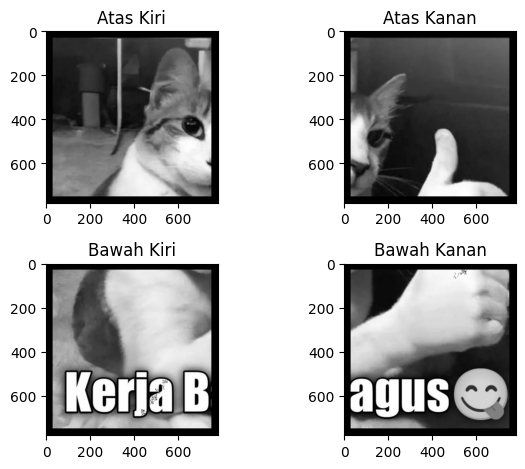

In [251]:
def dilatasi(image):
    h, w = image.shape
    hasil = np.zeros((h*2, w*2), dtype=image.dtype)
    
    for i in range(h*2):
        for j in range(w*2):
            hasil[i, j] = image[i//2, j//2]
    
    return hasil


atas_kiri = dilatasi(atas_kiri)
bawah_kanan = dilatasi(bawah_kanan)
atas_kanan = dilatasi(atas_kanan)
bawah_kiri = dilatasi(bawah_kiri)

plt.subplot(2, 2, 1)
plt.imshow(atas_kiri, cmap='gray')
plt.title('Atas Kiri')
plt.subplot(2, 2, 2)
plt.imshow(bawah_kanan, cmap='gray')
plt.title('Atas Kanan')
plt.subplot(2, 2, 3)
plt.imshow(atas_kanan, cmap='gray')
plt.title('Bawah Kiri')
plt.subplot(2, 2, 4)
plt.imshow(bawah_kiri, cmap='gray')
plt.title('Bawah Kanan')
plt.tight_layout()

Fungsi dilatasi tersebut melakukan perbesaran citra dengan skala dua kali lipat menggunakan teknik interpolasi tetangga terdekat atau nearest neighbor. Cara kerjanya adalah dengan menduplikasi setiap piksel tunggal dari citra asli menjadi blok berukuran 2x2 pada citra baru yang dimensinya telah digandakan. Setelah fungsi ini diterapkan pada keempat potongan kuadran, hasilnya ditampilkan kembali dalam susunan grid untuk memperlihatkan bahwa setiap bagian gambar kini memiliki resolusi dimensi yang lebih besar namun tetap mempertahankan detail visual yang sama secara blok.

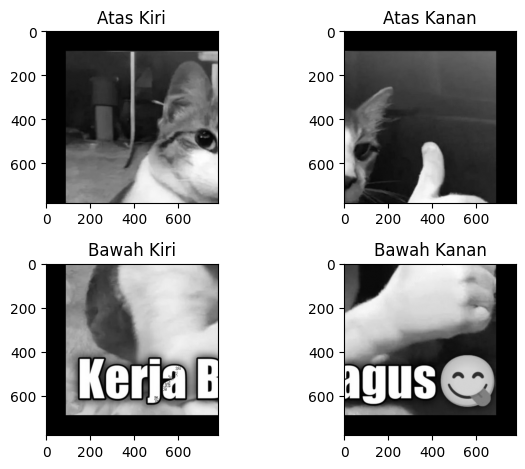

In [261]:
def translasi(image, dx, dy):
    h, w = image.shape
    hasil = np.zeros_like(image)
    
    for i in range(h):
        for j in range(w):
            ni = i + dy
            nj = j + dx
            
            if 0 <= ni < h and 0 <= nj < w:
                hasil[ni, nj] = image[i, j]
    
    return hasil

atas_kiri = translasi(atas_kiri, 30, 30)
bawah_kanan = translasi(bawah_kanan, -30, 30)
atas_kanan = translasi(atas_kanan, 30, -30)
bawah_kiri = translasi(bawah_kiri, -30, -30)

plt.subplot(2, 2, 1)
plt.imshow(atas_kiri, cmap='gray')
plt.title('Atas Kiri')
plt.subplot(2, 2, 2)
plt.imshow(bawah_kanan, cmap='gray')
plt.title('Atas Kanan')
plt.subplot(2, 2, 3)
plt.imshow(atas_kanan, cmap='gray')
plt.title('Bawah Kiri')
plt.subplot(2, 2, 4)
plt.imshow(bawah_kiri, cmap='gray')
plt.title('Bawah Kanan')
plt.tight_layout()

Text(0.5, 1.0, 'Hasil Susun')

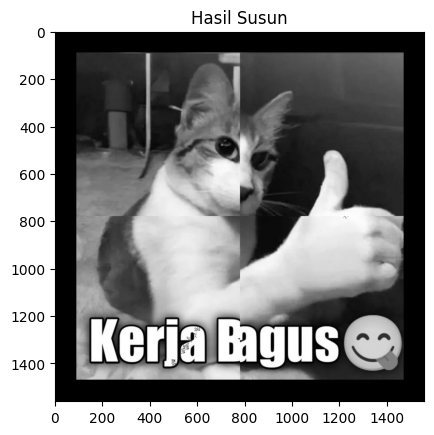

In [262]:
atas = np.hstack((atas_kiri, bawah_kanan))
bawah = np.hstack((atas_kanan, bawah_kiri))
final = np.vstack((atas, bawah))

plt.imshow(final, cmap='gray')
plt.title('Hasil Susun')

Kode ini berfungsi untuk menampilkan distribusi frekuensi nilai piksel dari citra final dalam bentuk histogram. Fungsi ravel digunakan untuk meratakan array citra dua dimensi menjadi satu baris panjang, sedangkan parameter bins setingkat 256 mewakili seluruh rentang intensitas warna dari 0 hingga 255. Histogram ini memberikan gambaran visual mengenai tingkat kecerahan citra, di mana akumulasi data akan terlihat lebih bergeser ke arah kiri atau angka yang lebih rendah karena nilai piksel sebelumnya telah dibagi dua.

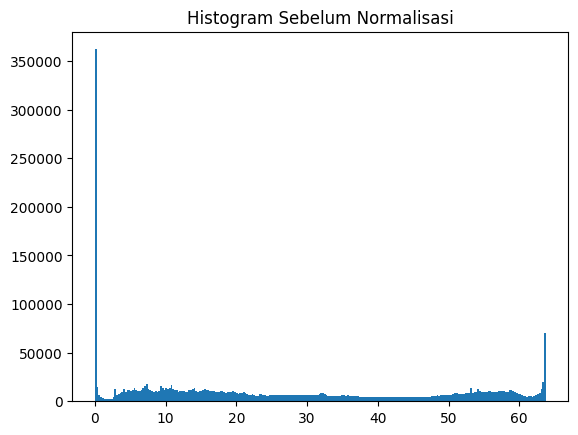

In [256]:
final = final / 2

plt.hist(final.ravel(), bins=256)
plt.title('Histogram Sebelum Normalisasi')
plt.show()

Kode ini melakukan normalisasi nilai piksel pada citra agar kembali berada dalam rentang standar 0 hingga 255. Proses ini dilakukan dengan mengurangkan nilai piksel dengan nilai minimumnya, lalu membaginya dengan rentang (nilai maksimum dikurangi nilai minimum), dan mengalikannya dengan 255. Dengan melakukan ini, kontras citra yang sebelumnya meredup akibat pembagian dua akan kembali optimal, dan histogram yang dihasilkan akan menunjukkan distribusi intensitas yang lebih tersebar merata di seluruh rentang warna.

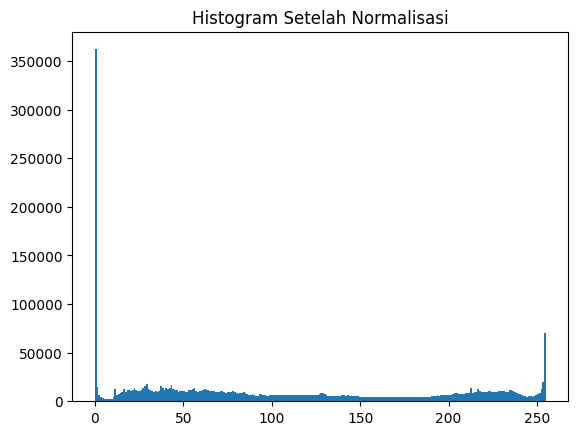

In [257]:
norm = (final - final.min()) / (final.max() - final.min()) * 255

plt.hist(norm.ravel(), bins=256)
plt.title('Histogram Setelah Normalisasi')
plt.show()

Kode ini melakukan operasi konvolusi pada citra yang telah dinormalisasi menggunakan kernel berukuran 4x4. Pertama, citra diberikan bantalan (padding) di sekelilingnya agar ukuran output tetap sama dengan input, lalu dilakukan perulangan untuk mengalikan setiap bagian citra sebesar 4x4 dengan nilai kernel tersebut dan menjumlahkan hasilnya. Kernel yang digunakan memiliki karakteristik untuk mendeteksi fitur atau tepi pada citra karena kombinasi nilai negatif di sekeliling dan nilai positif di tengah. Hasil operasi ini disimpan ke dalam array hasil_konv yang merepresentasikan citra hasil pemrosesan filter tersebut.

In [ ]:
kernel = np.array([
[-0.1, -0.1, -0.1, -0.1],
[-0.1,  0.4,  0.4, -0.1],
[-0.1,  0.4,  0.4, -0.1],
[-0.1, -0.1, -0.1, -0.1]
])

pad = np.pad(norm, ((3,3),(3,3)), mode='constant')

h, w = norm.shape
hasil_konv = np.zeros((h, w))

for i in range(h):
    for j in range(w):
        hasil_konv[i,j] = np.sum(pad[i:i+4, j:j+4] * kernel)

Kode ini berfungsi untuk membatasi nilai intensitas piksel hasil konvolusi agar tetap berada dalam rentang standar 0 hingga 255 menggunakan fungsi clip. Langkah ini sangat penting karena operasi matriks pada tahap konvolusi sebelumnya bisa menghasilkan nilai di luar batas tersebut yang tidak dapat ditampilkan dengan benar sebagai gambar. Setelah nilai piksel dipastikan aman, citra hasil akhirnya ditampilkan dalam format grayscale tanpa garis sumbu koordinat sebagai representasi visual dari seluruh proses pengolahan yang telah dilakukan.

In [ ]:
hasil_konv = np.clip(hasil_konv, 0, 255)

plt.imshow(hasil_konv, cmap='gray')
plt.title('Hasil Akhir')